#### **Data Augmentation in Deep Learning**

**Data Augmentation** is a technique used to **artificially increase the size and diversity of a training dataset** by creating modified versions of existing data. It is especially common in **Computer Vision and CNNs** where we can modify images while keeping their original labels.

#### **Why do we need Data Augmentation?**

Suppose we have only 1,000 images of cats and dogs. A CNN may memorize the training images instead of learning general features. This is called **overfitting**. Data augmentation creates different versions of the same images:

```text
                Original Image
          ┌───────────┼───────────┐
          ▼           ▼           ▼
       Rotation    Flipping     Cropping
          ▼           ▼           ▼
       New Image   New Image    New Image
          └───────────┼───────────┘
                      ▼
                Larger Dataset
                      ▼
                Train CNN
```
For example:
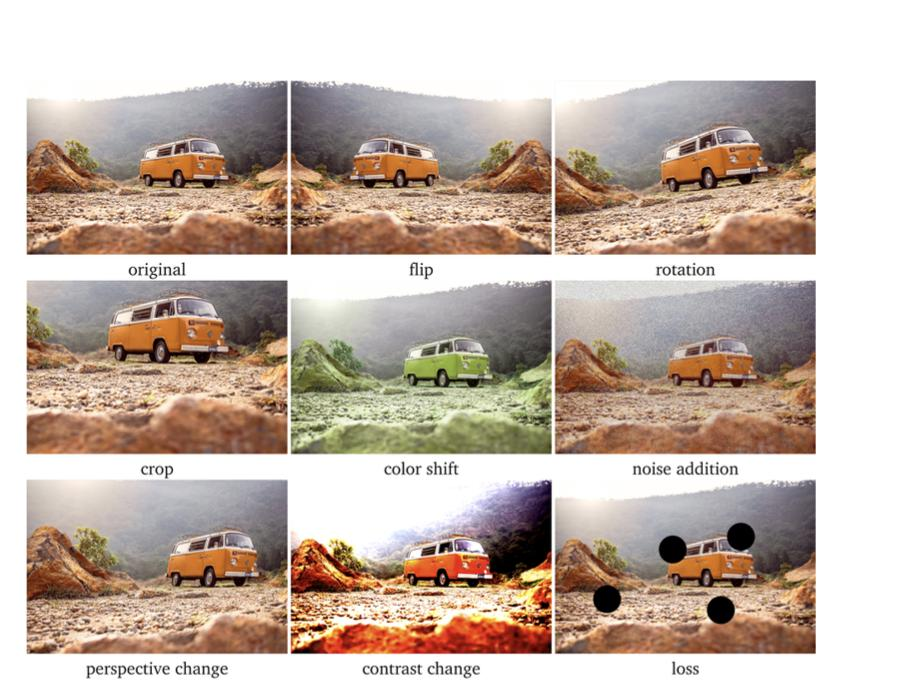

---

#### **Common Data Augmentation Techniques**

**1. Rotation:** Rotate an image by a small angle. This can help the model recognize objects at different orientations. Example:

```python
transforms.RandomRotation(20)
```

---

**2. Horizontal Flip:** Flip the image from left to right.

```python
transforms.RandomHorizontalFlip()
```

---

**3. Random Crop:** Randomly crop a portion of the image. This teaches the model to recognize an object even when it is not perfectly centered.

```python
transforms.RandomCrop(224)
```

---

**4. Resize:** Change the image size. CNNs commonly require images to have a consistent size.

```python
transforms.Resize((224, 224))
```

---

**5. Brightness and Contrast:** Change the lighting conditions. This helps when images are taken under different lighting conditions.

```python
transforms.ColorJitter(
    brightness=0.2,
    contrast=0.2
)
```

---

**6. Zoom:** Randomly zoom into or out of an image. This helps the model learn features at different scales.

```python
transforms.RandomResizedCrop(224)
```

---

#### **Data Augmentation in PyTorch**

`torchvision.transforms` is the most important tool to learn for image augmentation.

```python
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])
```

Then use it with a dataset:

```python
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    "data/train",
    transform=train_transform
)
```

Every time an image is loaded during training, the random transformations can produce a **slightly different version** of that image.

---

#### **Data Augmentation vs Original Dataset**

Suppose the original dataset contains:

```text
Image 1 → Cat
Image 2 → Cat
Image 3 → Dog
Image 4 → Dog
```

After augmentation, the model may see:

```text
Original Cat       Original Dog
   ↓                   ↓
Flipped Cat        Flipped Dog
Rotated Cat        Rotated Dog
Cropped Cat        Cropped Dog
Bright Cat         Dark Dog
```

So the model learns **"What makes this a cat or dog?"** rather than **"What does this exact training image look like?"**

---

**Important Rule:** Augment Training Data, Not Validation/Test Data. Because validation/test data should represent **real, unseen data**. Applying random augmentation during evaluation can make the performance measurement less reliable.

---

#### **Benefits**

Data augmentation can:

* Reduce **overfitting**
* Increase dataset diversity
* Improve **generalization**
* Make CNNs more robust
* Reduce dependence on collecting huge numbers of images
* Improve performance when the dataset is small

---

#### **Complete Data Augmentation Implementation in PyTorch**

We will use a **Cat vs Dog classification** example.

#### **Project structure**

```text
dataset/
│
├── train/
│   ├── cats/
│   │   ├── cat1.jpg
│   │   ├── cat2.jpg
│   │   └── ...
│   │
│   └── dogs/
│       ├── dog1.jpg
│       ├── dog2.jpg
│       └── ...
│
└── test/
    ├── cats/
    │   ├── cat1.jpg
    │   └── ...
    │
    └── dogs/
        ├── dog1.jpg
        └── ...
```

---

#### **Import Libraries**

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

---

#### **Check GPU**

If you have an NVIDIA GPU with CUDA `Device: cuda` Otherwise `Device: cpu`.

In [11]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print("Device: ", device)

Device:  cpu


---

#### **Define Data Augmentation**

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Convert image to Tensor
    transforms.ToTensor(),

    # Normalize
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

---

#### **Transform for Test Data**

We **do not use random augmentation on test data**.

In [13]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

So:

```text
Training: Image → Augmentation → Tensor → CNN
Testing:  Image → Resize → Tensor → CNN
```

---

#### **Load the Dataset**

`ImageFolder` automatically detects the classes from the folder names.

In [14]:
train_dataset = datasets.ImageFolder(
    root="dataset/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root="dataset/test",
    transform=test_transform
)

**Check the classes:**

In [15]:
print("Classes: ", train_dataset.classes)

Classes:  ['cats', 'dogs']


---

#### **Create DataLoaders**

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=10,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=10,
    shuffle=False,
    num_workers=0
)

#### **Why `shuffle=True`?**

During training, we want the images to appear in a random order. This helps training.

---

#### **Look at Augmented Images**

Let's visualize the effect of augmentation.

In [17]:
images, labels = next(iter(train_loader))
print("Batch shape: ", images.shape)
print("Labels: ", labels)

Batch shape:  torch.Size([10, 3, 224, 224])
Labels:  tensor([1, 0, 1, 0, 1, 1, 0, 1, 1, 1])


---

#### **Display Images**

Because we normalized the images, we need to reverse normalization before displaying them.

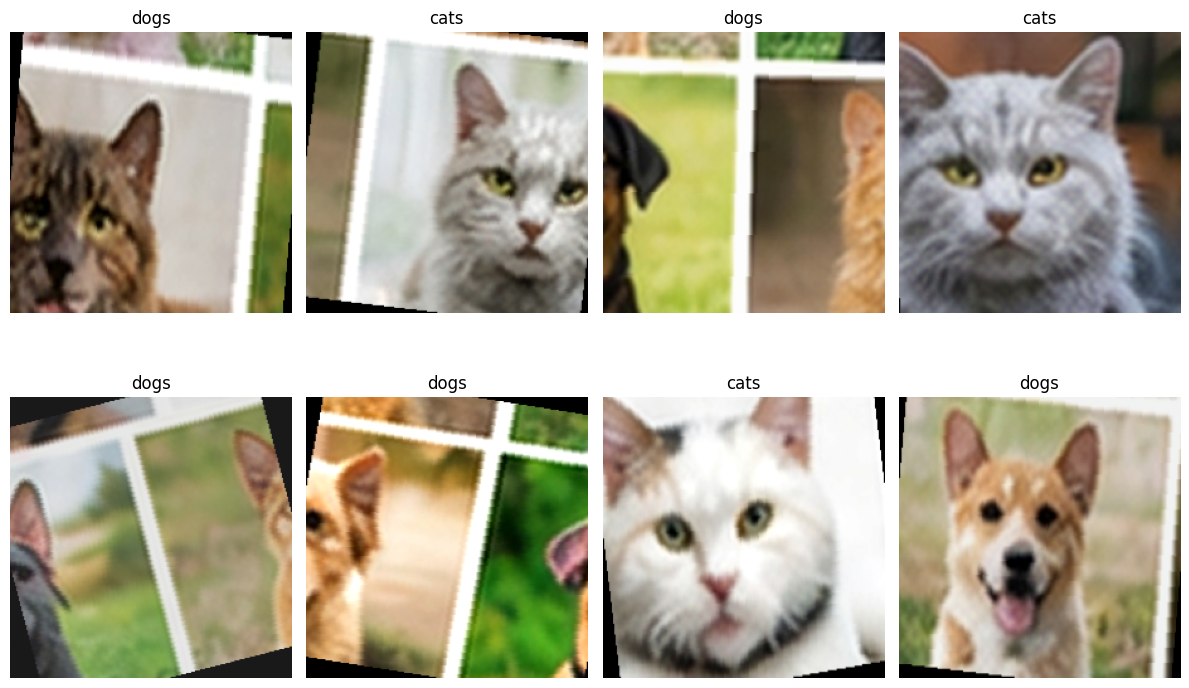

In [18]:
def denormalize(image):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean
    return torch.clamp(image, 0, 1)

# Now display some images
plt.figure(figsize=(12, 8))

for i in range(8):
    image = denormalize(images[i])
    image = image.permute(1, 2, 0)
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()